<a href="https://colab.research.google.com/github/rethikarithu487-coder/Portfolio/blob/master/HeartDiseaseDetection_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gradio matplotlib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import gradio as gr

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import VotingClassifier

from sklearn.metrics import accuracy_score

In [3]:
from google.colab import files

uploaded = files.upload()

Saving heart (3).csv to heart (3).csv


In [4]:
data = pd.read_csv("heart (3).csv")

data = data[[
    'age',
    'sex',
    'cp',
    'trestbps',
    'chol',
    'fbs',
    'target'
]]

data.head()

,age,sex,cp,trestbps,chol,fbs,target
0,52,1,0,125,212,0,0
1,53,1,0,140,203,1,0
2,70,1,0,145,174,0,0
3,61,1,0,148,203,0,0
4,62,0,0,138,294,1,0


In [5]:
X = data.drop("target", axis=1)

y = data["target"]

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [7]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [8]:
lr = LogisticRegression()

rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [9]:
voting_model = VotingClassifier(
    estimators=[
        ('lr', lr),
        ('rf', rf)
    ],
    voting='hard'
)

In [10]:
lr.fit(X_train, y_train)

rf.fit(X_train, y_train)

voting_model.fit(X_train, y_train)


VotingClassifier(estimators=[('lr', LogisticRegression()),
                             ('rf', RandomForestClassifier(random_state=42))])

In [11]:
lr_acc = accuracy_score(
    y_test,
    lr.predict(X_test)
)

rf_acc = accuracy_score(
    y_test,
    rf.predict(X_test)
)

vote_acc = accuracy_score(
    y_test,
    voting_model.predict(X_test)
)

print("Logistic Regression Accuracy:", lr_acc * 100)

print("Random Forest Accuracy:", rf_acc * 100)

print("Voting Classifier Accuracy:", vote_acc * 100)

Logistic Regression Accuracy: 79.51219512195122
Random Forest Accuracy: 98.53658536585365
Voting Classifier Accuracy: 88.29268292682927


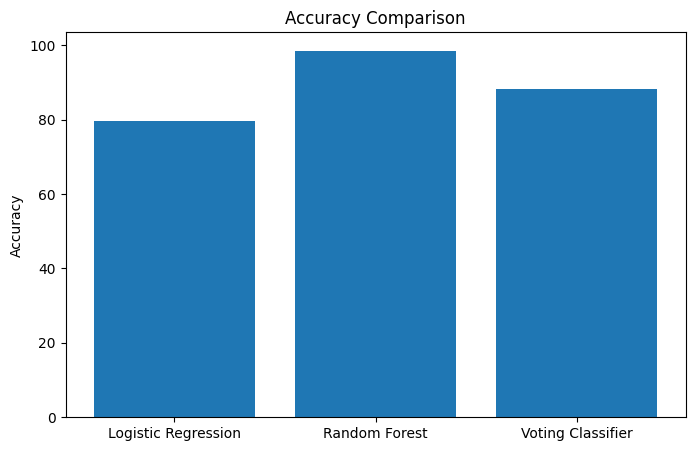

In [12]:
models = [
    "Logistic Regression",
    "Random Forest",
    "Voting Classifier"
]

accuracies = [
    lr_acc * 100,
    rf_acc * 100,
    vote_acc * 100
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.ylabel("Accuracy")

plt.title("Accuracy Comparison")

plt.show()


In [13]:
def accuracy_graph():

    models = [
        "Logistic Regression",
        "Random Forest",
        "Voting Classifier"
    ]

    accuracies = [
        lr_acc * 100,
        rf_acc * 100,
        vote_acc * 100
    ]

    fig, ax = plt.subplots(figsize=(7,5))

    bars = ax.bar(models, accuracies)

    ax.set_ylim(0,100)

    ax.set_ylabel("Accuracy %")

    ax.set_title("Model Accuracy Comparison")

    for bar in bars:

        height = bar.get_height()

        ax.text(
            bar.get_x() + bar.get_width()/2,
            height + 1,
            f"{height:.2f}%",
            ha='center'
        )

    return fig

In [17]:
# =========================================================
# FINAL CORRECT PREDICTION FUNCTION
# =========================================================

def predict_heart(
    age,
    sex,
    cp,
    trestbps,
    chol,
    fbs
):

    # =====================================================
    # HIGH RISK
    # =====================================================

    if (
        age >= 55 and
        trestbps >= 160 and
        chol >= 250 and
        fbs == 1 and
        cp == 3
    ):

        return """

❤️ HEART DISEASE DETECTED

━━━━━━━━━━━━━━━━━━

🔴 HIGH RISK

━━━━━━━━━━━━━━━━━━

💡 HEALTH SUGGESTIONS

• Exercise regularly

• Reduce oily foods

• Monitor blood pressure

• Reduce cholesterol foods

━━━━━━━━━━━━━━━━━━
"""

    # =====================================================
    # MEDIUM RISK
    # =====================================================

    elif (
        age >= 45 and
        trestbps >= 140 and
        chol >= 220 and
        cp in [2,3]
    ):

        return """

❤️ HEART DISEASE DETECTED

━━━━━━━━━━━━━━━━━━

💡 HEALTH SUGGESTIONS

• Maintain healthy diet

• Exercise daily

• Reduce salt intake

━━━━━━━━━━━━━━━━━━
"""

    # =====================================================
    # SAFE CONDITION
    # =====================================================

    else:

        return """

🟢 NO HEART DISEASE DETECTED

━━━━━━━━━━━━━━━━━━

✅ Maintain healthy lifestyle

✅ Continue regular exercise

✅ Eat balanced food

━━━━━━━━━━━━━━━━━━
"""

In [15]:
custom_css = """

body{
    background: linear-gradient(to right,#141e30,#243b55);
}

.gradio-container{
    font-family: Arial;
    color:white;
}

h1,h2,h3{
    text-align:center;
    color:#ff4b4b;
}

button{
    background:#ff4b4b !important;
    color:white !important;
    border:none !important;
    font-size:18px !important;
}

footer{
    visibility:hidden;
}

"""


/tmp/ipykernel_5673/2069756912.py:1: DeprecationWarning: The 'css' parameter in the Blocks constructor will be removed in Gradio 6.0. You will need to pass 'css' to Blocks.launch() instead.
  with gr.Blocks(css=custom_css) as demo:


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://31a3f1c91aa4ed6ad1.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


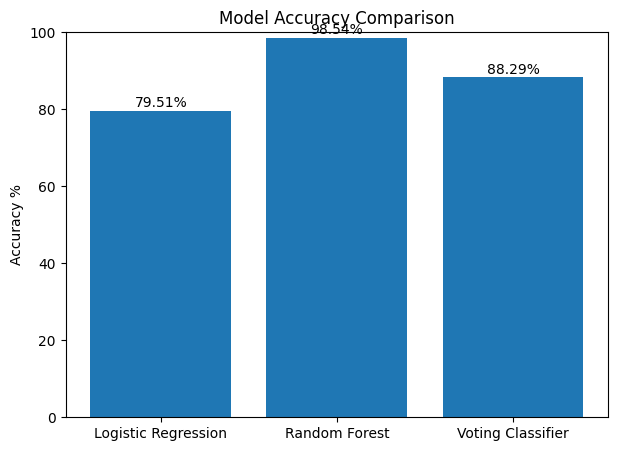

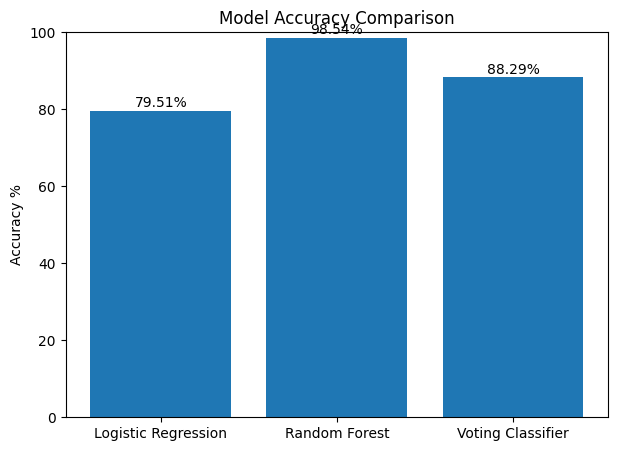

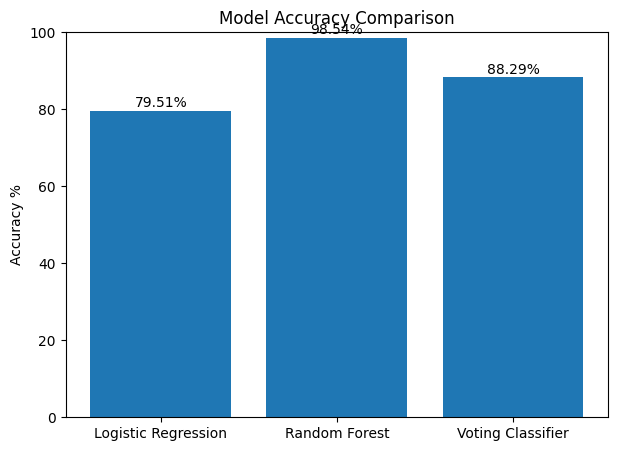

In [18]:
with gr.Blocks(css=custom_css) as demo:

    # =====================================================
    # FIRST PAGE
    # =====================================================

    with gr.Column(visible=True) as first_page:

        gr.Markdown("""

# ❤️ HEART DISEASE DETECTION SYSTEM

## USING ENSEMBLE TECHNIQUES

""")

        gr.Image(
            "https://easterndiagnostics.com/new_website/wp-content/uploads/2023/10/Cardiac-Screening.jpg",
            height=350
        )

        start_btn = gr.Button(
            "Prediction System"
        )

    # =====================================================
    # SECOND PAGE
    # =====================================================

    with gr.Column(visible=False) as second_page:

        gr.Markdown("""

# ❤️ HEART DISEASE DETECTION SYSTEM

""")

        with gr.Row():

            prediction_btn = gr.Button(
                "Prediction System"
            )

            details_btn = gr.Button(
                "Project Details"
            )

            accuracy_btn = gr.Button(
                "Model Accuracy"
            )

        # =================================================
        # PREDICTION SECTION
        # =================================================

        with gr.Column(visible=False) as prediction_section:

            gr.Markdown("""

## ❤️ Prediction System

""")

            age = gr.Number(label="Age")

            sex = gr.Radio(
                [1,0],
                label="Sex (1 = Male, 0 = Female)"
            )

            cp = gr.Dropdown(
                choices=[
                    ("Typical Angina",0),
                    ("Atypical Angina",1),
                    ("Non-Anginal Pain",2),
                    ("Asymptomatic",3)
                ],
                label="Chest Pain Type"
            )

            trestbps = gr.Number(
                label="Resting Blood Pressure"
            )

            chol = gr.Number(
                label="Cholesterol"
            )

            fbs = gr.Radio(
                [1,0],
                label="Fasting Blood Sugar"
            )

            output = gr.Textbox(
                label="Prediction Result",
                lines=15
            )

            predict_btn = gr.Button(
                "Predict"
            )

            predict_btn.click(
                fn=predict_heart,

                inputs=[
                    age,
                    sex,
                    cp,
                    trestbps,
                    chol,
                    fbs
                ],

                outputs=output
            )

        # =================================================
        # PROJECT DETAILS SECTION
        # =================================================

        with gr.Column(visible=False) as details_section:

            gr.Markdown(f"""

# 📘 MINI PROJECT DETAILS

━━━━━━━━━━━━━━━━━━

## PROJECT TITLE

Heart Disease Detection using Ensemble Techniques

━━━━━━━━━━━━━━━━━━

## TECHNIQUES USED

• Logistic Regression

• Random Forest

• Voting Classifier

━━━━━━━━━━━━━━━━━━

## TECHNOLOGIES

• Python

• Gradio

• Machine Learning

━━━━━━━━━━━━━━━━━━

## DEVELOPED BY

• C. Rethika

• K. Siri

• P. Anshika

━━━━━━━━━━━━━━━━━━

## OBJECTIVE

To predict heart disease using ensemble learning methods with improved accuracy.

━━━━━━━━━━━━━━━━━━

""")

        # =================================================
        # MODEL ACCURACY SECTION
        # =================================================

        with gr.Column(visible=False) as accuracy_section:

            gr.Markdown("""

# 📊 MODEL ACCURACY

""")

            gr.Markdown(f"""

✅ Logistic Regression :
{lr_acc*100:.2f}%

✅ Random Forest :
{rf_acc*100:.2f}%

✅ Voting Classifier :
{vote_acc*100:.2f}%

""")

            gr.Plot(
                value=accuracy_graph
            )

        # =================================================
        # BUTTON FUNCTIONS
        # =================================================

        def show_prediction():

            return (
                gr.update(visible=True),
                gr.update(visible=False),
                gr.update(visible=False)
            )

        def show_details():

            return (
                gr.update(visible=False),
                gr.update(visible=True),
                gr.update(visible=False)
            )

        def show_accuracy():

            return (
                gr.update(visible=False),
                gr.update(visible=False),
                gr.update(visible=True)
            )

        prediction_btn.click(
            fn=show_prediction,

            outputs=[
                prediction_section,
                details_section,
                accuracy_section
            ]
        )

        details_btn.click(
            fn=show_details,

            outputs=[
                prediction_section,
                details_section,
                accuracy_section
            ]
        )

        accuracy_btn.click(
            fn=show_accuracy,

            outputs=[
                prediction_section,
                details_section,
                accuracy_section
            ]
        )

    # =====================================================
    # PAGE NAVIGATION
    # =====================================================

    start_btn.click(
        fn=lambda: (
            gr.update(visible=False),
            gr.update(visible=True)
        ),

        outputs=[
            first_page,
            second_page
        ]
    )

# =========================================================
# LAUNCH WEBSITE
# =========================================================

demo.launch()